In [1]:
# 변수의 shape, type, value 확인
def p(var,_str='') :
    if _str=='\n' or _str=='cr' :
        _str = '\n'
    else :
        print(f'[{_str}]:')
        _str = ''
    if type(var)!=type([]):
        try:
            print(f'Shape:{var.shape}')
        except :
            pass
    print(f'Type: {type(var)}')
    print(f'Values: {var}'+_str)

def pst(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}, {type(_x)}')
def ps(_x,_name=""):
    print(f'[{_name}] Shape{_x.shape}')

In [2]:
%%capture
!pip -q install lightning torchinfo

# **실습:  Convolutional Auto Encoder**


## **Import Module**

In [3]:
import torch
from torch import nn
from torch.nn import functional as F
from torchmetrics import functional as FM
from torch.utils.data import DataLoader, random_split
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.transforms import v2
import torchvision
from torchinfo import summary

import lightning as L
from lightning.pytorch import Trainer
from lightning.pytorch.callbacks import ModelCheckpoint
from lightning.pytorch.loggers import CSVLogger

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

device ='cuda:0'
torch.__version__,L.__version__

('2.8.0+cu126', '2.5.5')

## **DataSet**

### Load

In [4]:
from torchvision.datasets import FashionMNIST, MNIST

class AddNoise:
    def __init__(self, noise_rate=0.1):
        self.noise_rate=noise_rate
    def __call__(self, sample):
        image = np.asarray(sample.reshape(-1,))
        image += self.noise_rate * np.random.randn(image.shape[0])
        image = torch.from_numpy(image).to(torch.float32)
        image = image.view(1, 28, 28)
        return image

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    AddNoise(),])

download_root = './MNIST_DATASET'
train_dataset = MNIST(download_root, transform=transform, train=True, download=True)
test_dataset = MNIST(download_root, transform=transform, train=False, download=True)

trainDataLoader = DataLoader(train_dataset, batch_size=512, shuffle=True, num_workers=4)
testDataLoader = DataLoader(test_dataset, batch_size=512, shuffle=False, num_workers=4)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.52MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.6MB/s]


In [5]:
# Print out the shape
ps(train_dataset[0][0]) # Shapetorch.Size([1, 28, 28])
p(train_dataset[0][1])  # Type: <class 'int'> Values: 5

[] Shapetorch.Size([1, 28, 28])
[]:
Type: <class 'int'>
Values: 5


## **Model**

### Define

In [6]:
# AE4 model
class AE4(L.LightningModule):
    def __init__(self):
        super(AE4, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 8, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, padding=1),
            nn.Flatten(),
            nn.Linear(8*4*4, 2) )
        self.decoder = nn.Sequential(
            nn.Linear(2, 8*4*4),
            nn.Unflatten(1,(8,4,4)),
            nn.Conv2d(8, 8, 3, padding=1),
            nn.ReLU(),
            nn.Upsample((7,7)),
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU(),
            nn.Upsample((14,14)),
            nn.BatchNorm2d(16),
            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.Upsample((28,28)),
            nn.Conv2d(32, 1, 3, padding=1),
            nn.Sigmoid() )
    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

    def training_step(self, batch, batch_idx):
        x, _ = batch
        decoded = self(x.float())
        loss_mse = F.mse_loss(decoded, x)
        metrics={'loss':loss_mse}
        self.log_dict(metrics,prog_bar=True)
        return metrics

    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters())#, weight_decay=0.002)

ae4 = AE4().to(device)
summary(ae4, input_size=(32, 1, 28, 28))

Layer (type:depth-idx)                   Output Shape              Param #
AE4                                      [32, 1, 28, 28]           --
├─Sequential: 1-1                        [32, 2]                   --
│    └─Conv2d: 2-1                       [32, 32, 28, 28]          320
│    └─ReLU: 2-2                         [32, 32, 28, 28]          --
│    └─MaxPool2d: 2-3                    [32, 32, 14, 14]          --
│    └─Conv2d: 2-4                       [32, 16, 14, 14]          4,624
│    └─ReLU: 2-5                         [32, 16, 14, 14]          --
│    └─MaxPool2d: 2-6                    [32, 16, 7, 7]            --
│    └─BatchNorm2d: 2-7                  [32, 16, 7, 7]            32
│    └─Conv2d: 2-8                       [32, 8, 7, 7]             1,160
│    └─ReLU: 2-9                         [32, 8, 7, 7]             --
│    └─MaxPool2d: 2-10                   [32, 8, 4, 4]             --
│    └─Flatten: 2-11                     [32, 128]                 --
│    └─L

In [ ]:
ae4

AE4(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=1, dilation=1, ceil_mode=False)
    (10): Flatten(start_dim=1, end_dim=-1)
    (11): Linear(in_features=128, out_features=2, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=2, out_features=128, bias=True)
    (1): Unflatten(dim=1, unflattened_size=(8, 4, 4))
    (2): Conv2d(8, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Upsample(size

### Fit

In [7]:
%%time
ae4 = AE4()

name="AE4"
logger = CSVLogger("logs", name=name)
trainer = Trainer(max_epochs=30, logger=logger, accelerator='auto',
                  limit_train_batches=0.5,limit_val_batches=0.5)
trainer.fit(ae4, trainDataLoader)#, testDataLoader)
# Wall time: 1min 19s

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: You are using a CUDA device ('NVIDIA L4') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'hi

Training: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


CPU times: user 23 s, sys: 4.48 s, total: 27.5 s
Wall time: 1min 21s


In [9]:
name="AE4"
v_num = logger.version
history = pd.read_csv(f'./logs/{name}/version_{v_num}/metrics.csv')
df = history.groupby('epoch').last().drop('step', axis=1)

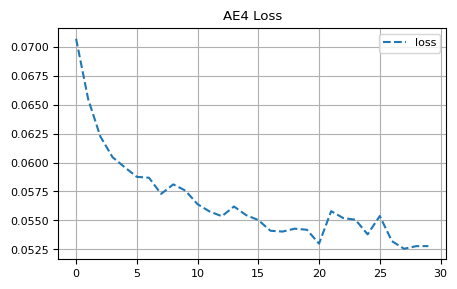

In [10]:
h1 = df

plt.figure(figsize=(5, 3))
plt.title(f"{name} Loss")
plt.plot(h1['loss'],'--', label='loss')
#plt.ylim(0.7, 1)
#plt.semilogy()
plt.legend()
plt.grid()
plt.show()

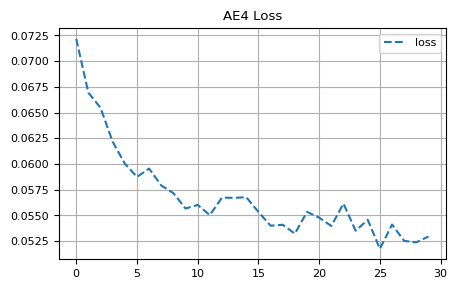

### Predict

In [11]:
# Input image
ps(test_dataset[0][0].unsqueeze(dim=0)) #(bs,ch,28,28)

[] Shapetorch.Size([1, 1, 28, 28])


In [12]:
# Decoded image
ps(ae4(test_dataset[0][0].unsqueeze(dim=0)))

[] Shapetorch.Size([1, 1, 28, 28])


In [13]:
# Predict
decoded_imgs = []
for i in range(9):
    decoded_imgs.append(ae4(test_dataset[i][0].unsqueeze(dim=0)))

ps(decoded_imgs[1])

[] Shapetorch.Size([1, 1, 28, 28])


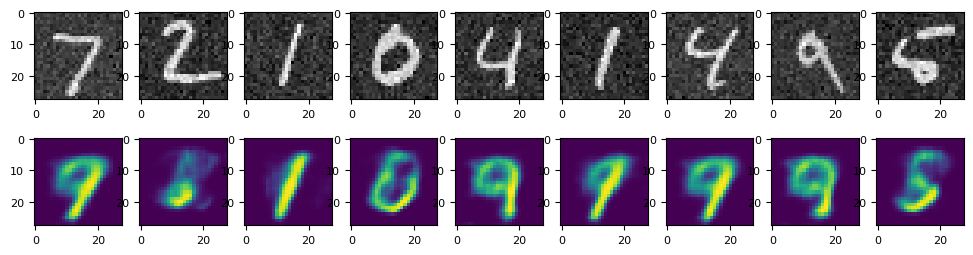

In [14]:
plt.figure(figsize=(12, 3))
num_imgs = 9
for i in range(num_imgs):
    # display original
    ax = plt.subplot(2, num_imgs, i + 1)
    true_img = test_dataset[i][0].reshape(28, 28)
    plt.imshow(true_img, cmap='gray')

    # display reconstruction
    ax = plt.subplot(2, num_imgs, i + 1 + num_imgs)
    reconstructed_img = decoded_imgs[i].reshape(28,28)
    plt.imshow(reconstructed_img.detach().numpy())
plt.show()

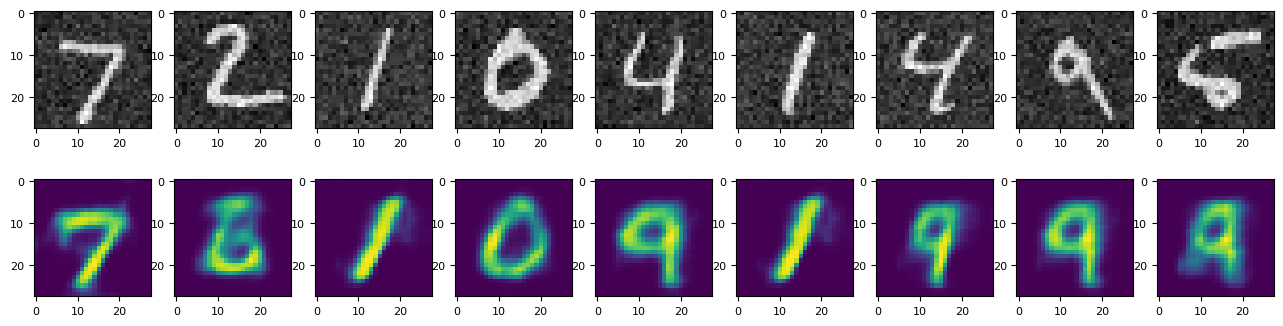

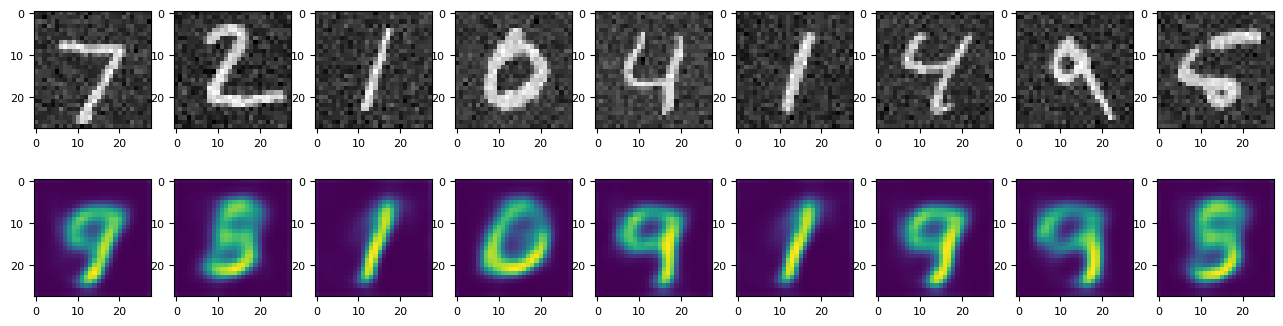

## **Analysis**

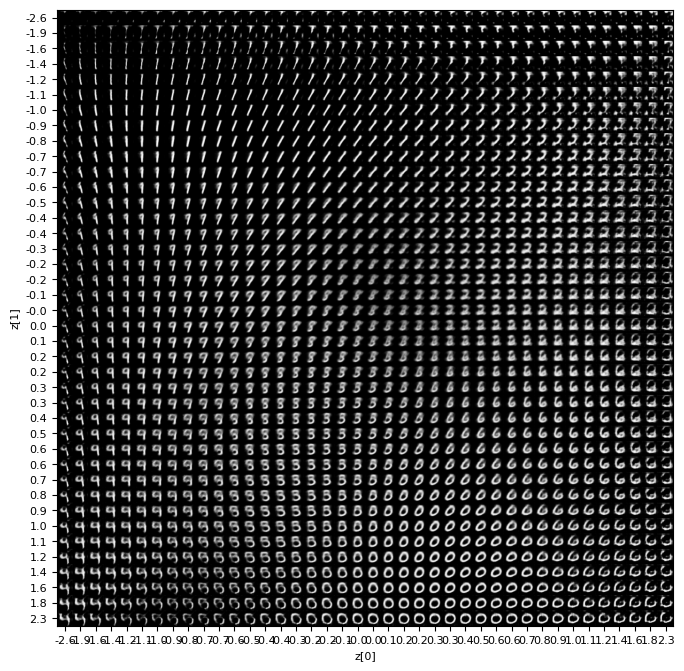

In [15]:
from scipy.stats import norm

batch_size = 1
n = 40 #40
figsize = 8

figure = np.zeros((28 * n, 28 * n))
grid_x = norm.ppf(np.linspace(0.005, 0.99, n))
grid_y = norm.ppf(np.linspace(0.005, 0.99, n))
ae4.eval()
with torch.no_grad():
  for i, xi in enumerate(grid_x):
    for j, yi in enumerate(grid_y):
      z_sample = np.array([[xi, yi]])

      # 그리드 좌표값으로 추론
      x_decoded = ae4.decoder.to(device)(torch.Tensor(z_sample).to(device))
      x_decoded = x_decoded.cpu().detach().numpy()
      digit = x_decoded[0].reshape(28, 28)

      figure[i * 28: (i + 1) * 28,
            j * 28: (j + 1) * 28] = digit

plt.figure(figsize=(figsize, figsize))
start_range = 28 // 2
end_range = n * 28 + start_range # + 1
pixel_range = np.arange(start_range, end_range, 28)
sample_range_x = np.round(grid_x, 1)
sample_range_y = np.round(grid_y, 1)
plt.xticks(pixel_range, sample_range_x)
plt.yticks(pixel_range, sample_range_y)
plt.xlabel("z[0]")
plt.ylabel("z[1]")
plt.imshow(figure, cmap="Greys_r")
plt.show()

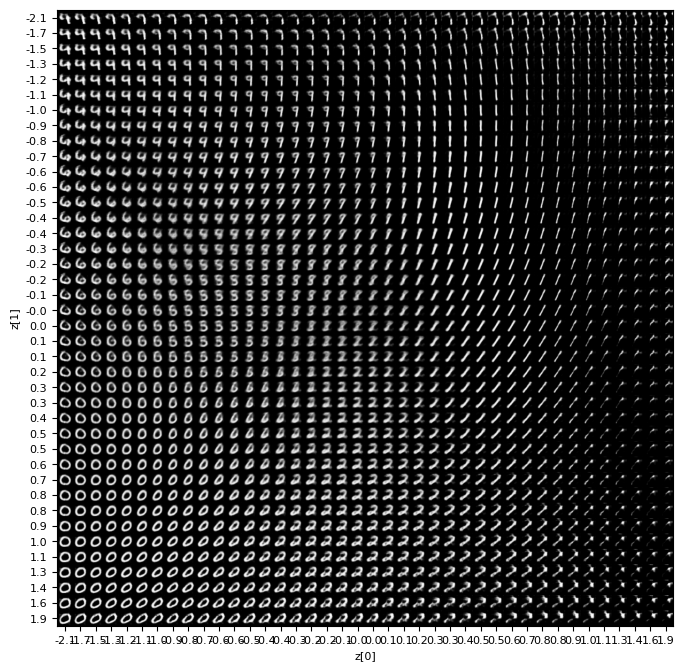

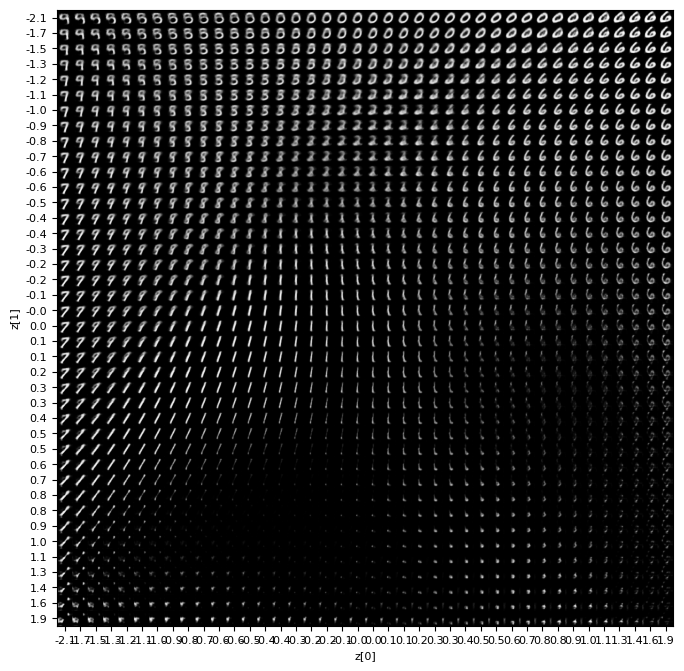

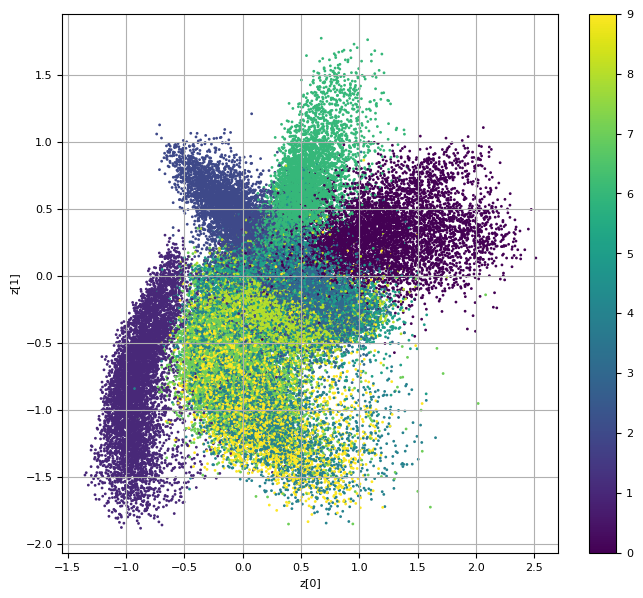

In [16]:
def plot_label_clusters(encoder, trainDataloader):
# display a 2D plot of the digit classes in the latent space
#    z_mean, _, _ = encoder2.predict(data) # data.shape:(60000,28,28,1)
    z_means = []
    labels = []
    for data, label in trainDataloader:
        # (60000,(z0,z1)) <- (60000,1,28,28)
        z_mean = encoder.to(device)(torch.Tensor(data).to(device))
        z_means.append(z_mean.cpu().detach().numpy())
        labels.append(label)
    z_means = np.concatenate(z_means)
    labels = np.concatenate(labels)
    # z_mean.shape:(60000,2)
    plt.figure(figsize=(8, 7))
    plt.scatter(z_means[:, 0], z_means[:, 1], c=labels, s=1) # z[0],z[1]
    plt.colorbar()
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    plt.grid()
    plt.show()

trainDataloader = DataLoader(train_dataset, shuffle=False, batch_size=512)
plot_label_clusters(ae4.encoder, trainDataloader)

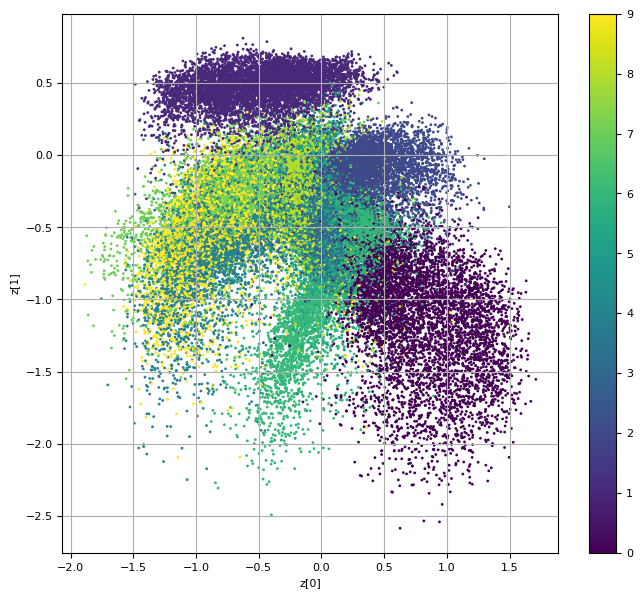

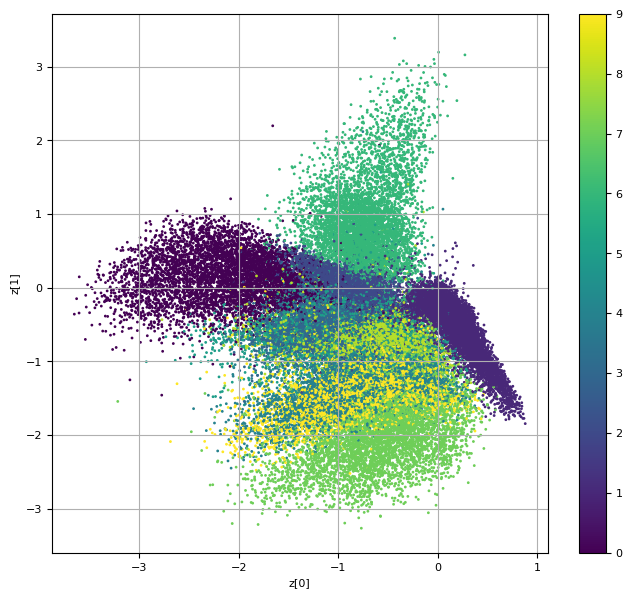